In [1]:
import mysql.connector
import pandas as pd

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="K.imanisha123*",   # replace with your MySQL password
    database="supermarket_sales_analysis"  # replace with your database name
)

print("Connected Successfully!")

Connected Successfully!


In [3]:
query = "SELECT * FROM sales_data"
df = pd.read_sql(query, conn)

df.head()

C:\Users\kotlu\AppData\Local\Temp\ipykernel_10768\1028432148.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,order_date,customer_name,city,product,category,quantity,price,payment_method
0,1,2024-01-05,Amit,Hyderabad,Laptop,Electronics,1,55000,UPI
1,2,2024-01-07,Sneha,Chennai,Mobile,Electronics,2,20000,Card
2,3,2024-01-10,Rahul,Bangalore,Shoes,Fashion,3,1500,Cash
3,4,2024-01-12,Priya,Hyderabad,Watch,Fashion,1,3000,UPI
4,5,2024-01-15,Kiran,Mumbai,Tablet,Electronics,2,18000,Card


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        10 non-null     int64 
 1   order_date      10 non-null     object
 2   customer_name   10 non-null     object
 3   city            10 non-null     object
 4   product         10 non-null     object
 5   category        10 non-null     object
 6   quantity        10 non-null     int64 
 7   price           10 non-null     int64 
 8   payment_method  10 non-null     object
dtypes: int64(3), object(6)
memory usage: 852.0+ bytes


In [5]:
df["total_amount"] = df["quantity"] * df["price"]

df.head()

,order_id,order_date,customer_name,city,product,category,quantity,price,payment_method,total_amount
0,1,2024-01-05,Amit,Hyderabad,Laptop,Electronics,1,55000,UPI,55000
1,2,2024-01-07,Sneha,Chennai,Mobile,Electronics,2,20000,Card,40000
2,3,2024-01-10,Rahul,Bangalore,Shoes,Fashion,3,1500,Cash,4500
3,4,2024-01-12,Priya,Hyderabad,Watch,Fashion,1,3000,UPI,3000
4,5,2024-01-15,Kiran,Mumbai,Tablet,Electronics,2,18000,Card,36000


In [6]:
df["total_amount"].sum()

np.int64(158800)

In [7]:
df.groupby("city")["total_amount"].sum()

city
Bangalore     9500
Chennai      46800
Hyderabad    62500
Mumbai       40000
Name: total_amount, dtype: int64

In [8]:
df.groupby("category")["total_amount"].sum()

category
Electronics    140500
Fashion         18300
Name: total_amount, dtype: int64

In [9]:
df.groupby("product")["total_amount"].sum().sort_values(ascending=False)

product
Laptop        55000
Mobile        40000
Tablet        36000
Headphones     5000
Bag            4800
Keyboard       4500
Shoes          4500
T-shirt        4000
Watch          3000
Sandals        2000
Name: total_amount, dtype: int64

In [11]:
df["payment_method"].value_counts()

payment_method
UPI     4
Card    3
Cash    3
Name: count, dtype: int64

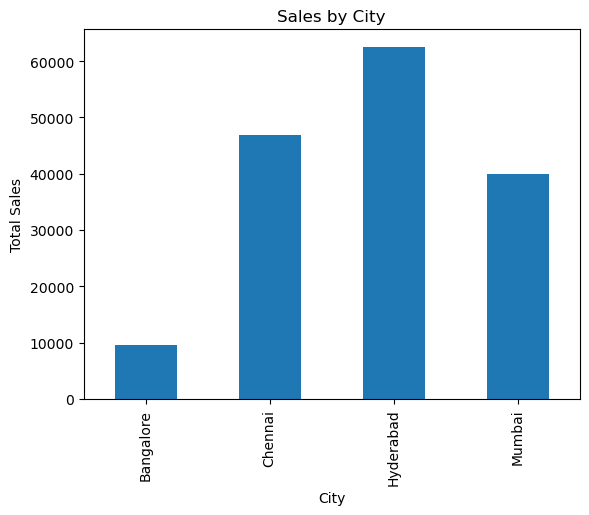

In [12]:
import matplotlib.pyplot as plt

city_sales = df.groupby("city")["total_amount"].sum()

city_sales.plot(kind="bar")
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

In [13]:
df.to_csv("sales_data_cleaned.csv", index=False)